What is a Vision Transformer — Before Any Code
CNN slides a small filter across the image looking at local regions one at a time. It never directly compares distant regions.
ViT divides the image into patches and lets every patch talk to every other patch simultaneously through a mechanism called self-attention.
CNN approach:                    ViT approach:
Look at 3×3 region               Divide into 4×4 patches
slide across image               Every patch looks at
build up local features          every other patch
                                 simultaneously

Good for:                        Good for:
textures, edges                  spatial relationships
local patterns                   position-dependent patterns
                                 "defect is in top-left
                                  corner relative to ring"
For wafer defects like Scratch and Loc where where the defect is relative to the whole wafer matters, ViT should outperform CNN.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import mlflow
import mlflow.pytorch
import math
import warnings
warnings.filterwarnings('ignore')

device = torch.device('mps')
print(f"Using: {device}")

with open('../data/processed/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

NUM_CLASSES = len(le.classes_)
CLASS_NAMES = le.classes_.tolist()
TARGET_SIZE = 64

print(f"Classes: {CLASS_NAMES}")
print(f"Num classes: {NUM_CLASSES}")

Using: mps
Classes: [np.str_('Center'), np.str_('Donut'), np.str_('Edge-Loc'), np.str_('Edge-Ring'), np.str_('Loc'), np.str_('Near-full'), np.str_('Random'), np.str_('Scratch'), np.str_('none')]
Num classes: 9


In [2]:
class WaferDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wafer = row['waferMap'].astype(np.float32)
        label = int(row['label_encoded'])
        img = Image.fromarray(wafer)
        img = img.resize((TARGET_SIZE, TARGET_SIZE), Image.NEAREST)
        wafer_norm = np.array(img) / 2.0
        tensor = torch.FloatTensor(wafer_norm).unsqueeze(0).repeat(3, 1, 1)
        if self.transform:
            tensor = self.transform(tensor)
        return tensor, label

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=90),
])

train_df = pd.read_pickle('../data/processed/train.pkl')
val_df   = pd.read_pickle('../data/processed/val.pkl')
test_df  = pd.read_pickle('../data/processed/test.pkl')

BATCH_SIZE = 64
train_loader = DataLoader(WaferDataset(train_df, transform=train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(WaferDataset(val_df),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(WaferDataset(test_df),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Loaders ready.")

Loaders ready.


In [3]:
class PatchEmbedding(nn.Module):
    """
    Step 1 of ViT: Divide image into patches and embed them.
    
    64×64 image with patch_size=8:
    → 8×8 = 64 patches total
    → each patch is 8×8×3 = 192 numbers
    → linear layer maps 192 → embed_dim (e.g. 256)
    """
    def __init__(self, img_size=64, patch_size=8, in_channels=3, embed_dim=256):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size
        # Conv layer with kernel=patch_size, stride=patch_size
        # effectively splits image into non-overlapping patches
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
        
    def forward(self, x):
        # x: (batch, 3, 64, 64)
        x = self.proj(x)          # (batch, embed_dim, 8, 8)
        x = x.flatten(2)          # (batch, embed_dim, 64)
        x = x.transpose(1, 2)     # (batch, 64, embed_dim)
        return x                  # 64 patches, each with embed_dim features


class MultiHeadSelfAttention(nn.Module):
    """
    Step 2 of ViT: Every patch looks at every other patch.
    
    'Attention' means: how much should patch A focus on patch B?
    
    If patch A is part of an Edge-Ring defect,
    it should pay high attention to other patches
    that are also part of the ring.
    
    'Multi-head' means we run this attention mechanism
    multiple times in parallel, each looking for
    different types of relationships.
    """
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # Self attention: query=key=value=x (patches attend to themselves)
        attended, _ = self.attention(x, x, x)
        # Residual connection (same idea as ResNet skip connections!)
        return self.norm(x + self.dropout(attended))


class TransformerBlock(nn.Module):
    """
    One complete Transformer block:
    1. Multi-head self attention (patches talk to each other)
    2. Feed forward network (each patch processes what it learned)
    Both use residual connections (skip connections like ResNet)
    """
    def __init__(self, embed_dim=256, num_heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        mlp_hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden),
            nn.GELU(),              # activation function
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, embed_dim),
            nn.Dropout(dropout)
        )
        
    def forward(self, x):
        x = self.attention(x)
        # Feed forward with residual connection
        return self.norm(x + self.dropout(self.mlp(x)))


class WaferViT(nn.Module):
    """
    Complete Vision Transformer for wafer defect classification.
    
    Architecture:
    Image → Patches → Embeddings → [Transformer × depth] → Classification
    """
    def __init__(self, img_size=64, patch_size=8, in_channels=3,
                 num_classes=9, embed_dim=256, depth=6,
                 num_heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        
        # Step 1: Split image into patches
        self.patch_embed = PatchEmbedding(img_size, patch_size,
                                          in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches
        
        # Step 2: Add [CLS] token
        # Special learnable token prepended to patch sequence
        # Its final state = summary of entire image = used for classification
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        
        # Step 3: Positional encoding
        # Transformers have no sense of order — we add position info
        # so patch #1 (top-left) is different from patch #64 (bottom-right)
        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        
        # Step 4: Stack of Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        
        # Step 5: Classification head
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        
        # Initialize weights properly
        self._init_weights()
        
    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        B = x.shape[0]             # batch size
        
        # Patch embedding: (B, 3, 64, 64) → (B, 64, 256)
        x = self.patch_embed(x)
        
        # Prepend CLS token: (B, 64, 256) → (B, 65, 256)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        
        # Add positional encoding
        x = self.pos_drop(x + self.pos_embed)
        
        # Pass through transformer blocks
        for block in self.blocks:
            x = block(x)
        
        x = self.norm(x)
        
        # Use only CLS token for classification
        cls_output = x[:, 0]      # (B, 256)
        return self.head(cls_output)  # (B, 9)


# Build model
model = WaferViT(
    img_size=64,
    patch_size=8,      # 64/8 = 8×8 = 64 patches
    num_classes=NUM_CLASSES,
    embed_dim=256,     # each patch represented as 256 numbers
    depth=6,           # 6 transformer blocks
    num_heads=8,       # 8 attention heads per block
    dropout=0.1
).to(device)

total = sum(p.numel() for p in model.parameters())
print(f"ViT parameters: {total:,}")
print(f"ResNet18 had:   11,000,000")

# Test forward pass
dummy = torch.randn(4, 3, 64, 64).to(device)
out = model(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}")

ViT parameters: 4,807,689
ResNet18 had:   11,000,000
Input shape:  torch.Size([4, 3, 64, 64])
Output shape: torch.Size([4, 9])


In [4]:
# Same sqrt weights that worked well
raw_weights = np.array([4.4754, 34.6241, 3.7035, 1.9852,
                         5.3490, 129.1858, 22.1834, 16.0975, 0.1303])
sqrt_weights = np.sqrt(raw_weights)
sqrt_weights = sqrt_weights / sqrt_weights.mean()
class_weights = torch.FloatTensor(sqrt_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# ViT needs warmup — start with tiny LR and ramp up
# then cosine decay. This is standard for transformers.
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

# Cosine annealing with warmup
def get_lr(epoch, warmup_epochs=5, total_epochs=20, base_lr=1e-4, min_lr=1e-6):
    if epoch < warmup_epochs:
        # Linear warmup
        return base_lr * (epoch + 1) / warmup_epochs
    else:
        # Cosine decay
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))

print("Loss, optimizer, scheduler ready.")
print("Using AdamW + warmup + cosine decay (standard for ViT)")

Loss, optimizer, scheduler ready.
Using AdamW + warmup + cosine decay (standard for ViT)


In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping — important for transformers
        # prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

print("Training functions ready.")

Training functions ready.


In [6]:
EPOCHS = 20
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

mlflow.set_experiment("wafer-vit")

with mlflow.start_run(run_name="vit_patch8_depth6_embed256"):
    mlflow.log_params({
        "model": "ViT",
        "patch_size": 8,
        "embed_dim": 256,
        "depth": 6,
        "num_heads": 8,
        "loss": "weighted_crossentropy",
        "weights": "sqrt_scaled",
        "optimizer": "adamw",
        "lr": 1e-4,
        "scheduler": "warmup_cosine",
        "epochs": EPOCHS
    })
    
    for epoch in range(EPOCHS):
        # Update LR manually each epoch
        lr = get_lr(epoch, warmup_epochs=5, total_epochs=EPOCHS)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        mlflow.log_metrics({
            "train_loss": train_loss, "val_loss": val_loss,
            "train_acc": train_acc,   "val_acc": val_acc,
            "lr": lr
        }, step=epoch)
        
        if (epoch + 1) % 5 == 0:
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
                'epoch': epoch + 1,
                'best_val_loss': best_val_loss
            }, f'../data/processed/vit_checkpoint_epoch{epoch+1}.pt')
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(),
                      '../data/processed/best_vit.pt')
            print(f"Epoch {epoch+1:02d}/{EPOCHS} ✓ BEST | lr={lr:.6f} | train_loss={train_loss:.4f} acc={train_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")
        else:
            print(f"Epoch {epoch+1:02d}/{EPOCHS}        | lr={lr:.6f} | train_loss={train_loss:.4f} acc={train_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")

print("\nViT Training complete!")

2026/04/27 14:33:17 INFO mlflow.tracking.fluent: Experiment with name 'wafer-vit' does not exist. Creating a new experiment.


Epoch 01/20 ✓ BEST | lr=0.000020 | train_loss=1.2643 acc=0.865 | val_loss=1.0460 acc=0.910


Epoch 02/20 ✓ BEST | lr=0.000040 | train_loss=0.9127 acc=0.893 | val_loss=0.8965 acc=0.894


Epoch 03/20 ✓ BEST | lr=0.000060 | train_loss=0.7173 acc=0.908 | val_loss=0.6454 acc=0.891


Epoch 04/20 ✓ BEST | lr=0.000080 | train_loss=0.6226 acc=0.915 | val_loss=0.5511 acc=0.931


...

Epoch 16/20 ✓ BEST | lr=0.000026 | train_loss=0.3549 acc=0.947 | val_loss=0.3656 acc=0.959


Epoch 17/20        | lr=0.000017 | train_loss=0.3472 acc=0.948 | val_loss=0.3839 acc=0.962


Epoch 18/20        | lr=0.000010 | train_loss=0.3399 acc=0.950 | val_loss=0.3920 acc=0.961


Epoch 19/20        | lr=0.000005 | train_loss=0.3283 acc=0.951 | val_loss=0.3885 acc=0.963


Epoch 20/20 ✓ BEST | lr=0.000002 | train_loss=0.3276 acc=0.951 | val_loss=0.3627 acc=0.960

ViT Training complete!


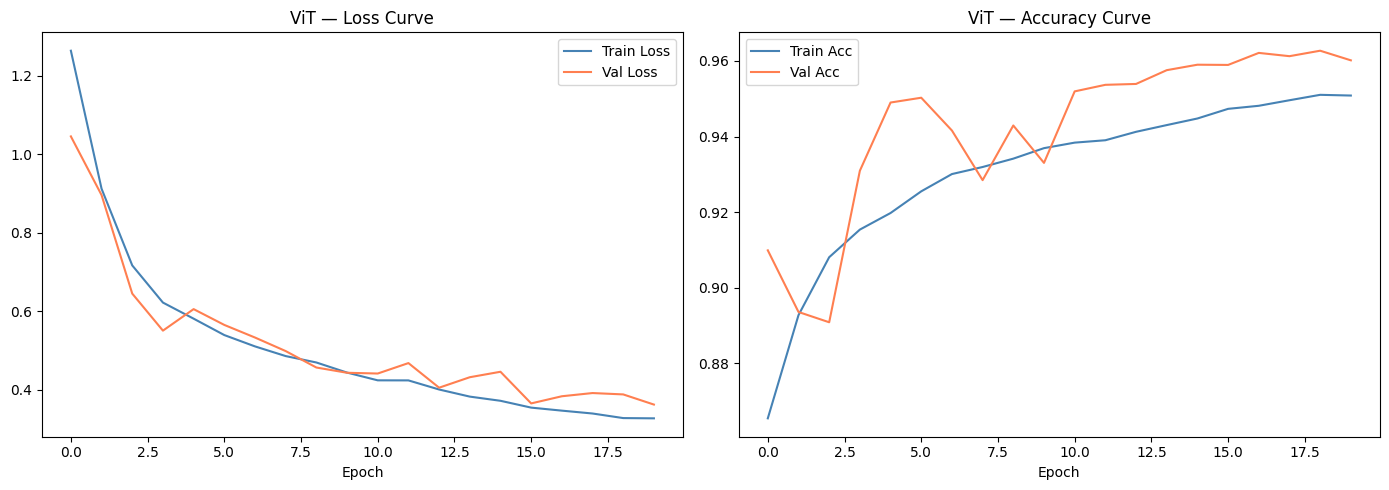

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='coral')
axes[0].set_title('ViT — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc', color='steelblue')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='coral')
axes[1].set_title('ViT — Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/vit_training_curves.png', dpi=150)
plt.show()

ViT Test Accuracy:          0.9620
Sqrt Weights Test Accuracy: 0.9667
Baseline Test Accuracy:     0.9526

              precision    recall  f1-score   support

      Center       0.91      0.91      0.91       430
       Donut       0.68      0.78      0.73        55
    Edge-Loc       0.79      0.72      0.75       519
   Edge-Ring       0.97      0.96      0.97       968
         Loc       0.70      0.64      0.67       360
   Near-full       0.88      1.00      0.94        15
      Random       0.90      0.88      0.89        86
     Scratch       0.27      0.24      0.25       119
        none       0.98      0.99      0.98     14743

    accuracy                           0.96     17295
   macro avg       0.79      0.79      0.79     17295
weighted avg       0.96      0.96      0.96     17295



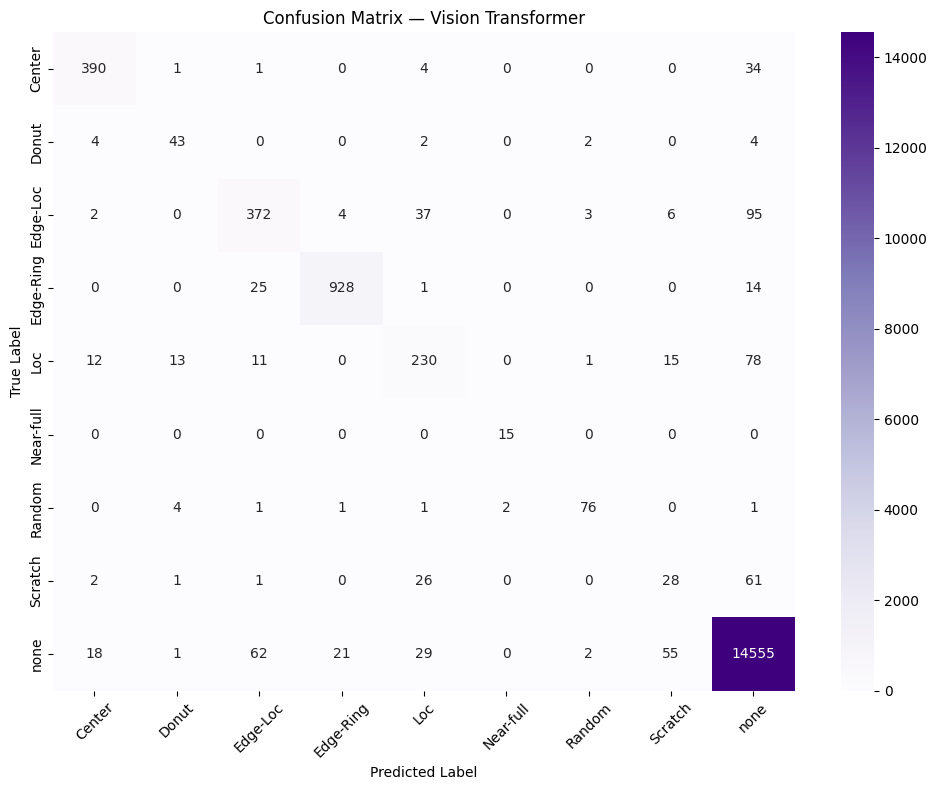

In [8]:
model.load_state_dict(torch.load('../data/processed/best_vit.pt',
                                  map_location=device))
_, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device)

print(f"ViT Test Accuracy:          {test_acc:.4f}")
print(f"Sqrt Weights Test Accuracy: 0.9667")
print(f"Baseline Test Accuracy:     0.9526")
print()
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Vision Transformer')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_vit.png', dpi=150)
plt.show()